# Unified plotting for Laughter paper: Duo Dance improv

extract physiological measurements and audio from externally hosted data, import annotation files describing dance events and laughter, compose plots for paper

In [1]:
import sys
import os
import time

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa

from scipy import interpolate

In [2]:
%load_ext autoreload
%autoreload 1
%aimport mh
%aimport rp2
%aimport viz
%aimport qex

In [3]:
 %reload_ext autoreload

# Import data constellation

In [4]:
Event = 'DanceImprov'
audio_loc='../DanceImprov/Video_Rehearsals/'
phys_dir ='../DanceImprov/Aligned/Physio/Segments/'
misc_loc = './datain/'
data_out = './dataout/'
plot_loc = './plots/'

Row_Order = ['Lisa','Ole'] #, 'VN203'
player_labels = {'Lisa':'Dancer 2','Ole':'Dancer 1'}
player_pallet = {'Dancer 1':[0.5,0.5,0.5], 'Dancer 2':'k'}
who_hatch = dict(zip(['Dancer 1','Dancer 2', 'contagious','simultaneous'],['\\','//',None,'.']))
alt_hatch={'solo':'//', 'group':None}


audiofiles = ['Colocated_Reh.wav','Lola_Reh.wav','Zoom2_Reh.wav']
offsets = {'Colocated':1.519, 'Zoom2':23.004 , 'Lola':3.849}
concert_dur = {'Colocated':3375,'Zoom2':2940.0,'Lola':2547}

segmentationfiles = {'Colocated':'CoLocated_Rehearsal_Panasonic_Cut_25fps_Segmentation.csv',
                   'Lola': 'LoLa_SidebySide_Rehearsal_Panasonic_25fps_Segmentation.csv',
                   'Zoom2':'30Zoom_SidebySide_Rehearsal_Panasonic_25fps_Segmentation.csv'}

annotationfiles = {'Colocated':'CoLocated_Rehearsal_Panasonic_Cut_25fps_labelled_updated.csv',
                   'Lola': 'LoLa_SidebySide_Rehearsal_Panasonic_25fps_labelled_updated.csv',
                   'Zoom2':'30Zoom_SidebySide_Rehearsal_Panasonic_25fps_labelled_updated.csv'}
whats = ['Mistake','Negotiation','Difficulty','Novelty','Joyful','Joke','Other']
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))

events_types = ['Search','Clean','Rehearse','Verbal']
eventType_code = dict(zip(events_types,['S','C','R','V']))
code_eventType =  dict(zip(['S','C','R','V'],events_types))

event_pallet=dict(zip(events_types,['#94bbdf','#bbb0e4','#e9a2cc','#ff9d9d'])) #['#4d8f98','#4d8bce','#ca65be','#ff494c']
event_hatch=dict(zip(events_types,['*','.',None,'x']))


## Sensor vest files

In [6]:
df_files = pd.DataFrame(columns=['PartID','Performance','Location','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            # print(f)
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==6:
                    df_files.loc[k,:] = {'PartID':dets[0],'Performance':dets[1],'Location':dets[2],'Segment':dets[3],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()

Load measurements for a specific session

In [18]:
concert = 'Colocated'
# concert = 'Zoom2'
# concert = 'Lola' #
Event = 'Rehearsal'
piece = Event + '_' + concert #'Linedancing'

players = Row_Order
collist = ['Lisa','Ole']
alist = ['Lisa','Ole']

shift_s = offsets[concert]

df_allfeats = {}
subfiles = PhysFiles.query('Performance==@concert and Segment==@Event')

altT = np.arange(0, concert_dur[concert],0.1) # Colocated 0.01 
df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
time_c = 'c_sTime'

all_sigs = {}

From the raw sensor values in the aligned measurement files, build dictionary of signals for plotting this session

In [59]:
# i=0

# Motion
sig = 'ACC'
for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: all_sigs[t] = df.copy()
subfiles = PhysFiles.query('Performance==@concert and Segment==@Event and Signal==@sig').copy()
subfiles.set_index('PartID',inplace=True)
for partID,row in subfiles.iterrows(): 
    V = pd.read_csv(row['FileLoc'],skipinitialspace=True)
    V.loc[:,'qom'] = np.sqrt(np.square(V.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1)).rolling(128).mean()
    V[time_c] = V[time_c]-shift_s
    times = V[time_c]
    f = interpolate.interp1d(times,V['Vert Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Vert'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V['Lat Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Lat'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V['Long Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Long'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V['qom'],kind = 'linear')    
    all_sigs['ACC_QoM'].loc[:,partID] = f(altT)

for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: df_allfeats[t] = all_sigs[t].copy()


# Respiration
df_feats = pd.DataFrame(index = altT,columns = collist)

sig = 'RESP'
subfiles = PhysFiles.query('Performance==@concert and Segment==@Event and Signal==@sig').copy()
subfiles.set_index('PartID',inplace=True)
sig = 'RespWave'
for partID,row in subfiles.iterrows(): #altEQCIBI
    R = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    R[time_c] = R[time_c]-shift_s
    R.set_index(time_c,inplace=True)
    if len(V)>10:
        Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(R['Breathing']),R['Breathing'])
        R['Breathing']= (R['Breathing']-R['Breathing'].median())/Breaths['IDepth'].quantile(0.15)
        f = interpolate.interp1d(R.index,R['Breathing'],fill_value='extrapolate')
        df_feats.loc[:,partID] = f(altT) 
        
df_allfeats[sig] = df_feats.copy()


# heart rate
df_feats = pd.DataFrame(index = altT,columns = collist)
sig = 'normHR1bt'
# sig = 'HR10bt'
meas = 'altEQCIBI' # RR files filtered for sensor noise
subfiles = PhysFiles.query('Performance==@concert and Segment==@Event and Measure==@meas').copy()
subfiles.set_index('PartID',inplace=True)

for partID,row in subfiles.iterrows(): #altEQCIBI
    V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    V[time_c] = V[time_c]-shift_s
    V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
    if len(V)>10:
        sig_t = V[time_c]
        sig_v = V['Interbeat Interval (MS)']
        IBI = mh.clean_IBI(sig_t,sig_v,activitytype='resp')
        HR = mh.ibi_feats(IBI.index,IBI.IBI.values,altT)
        df_feats.loc[:,partID] = HR[sig].values

df_allfeats[sig] = df_feats.copy()

df_smoothed = df_allfeats['normHR1bt'].copy()
for partID in Row_Order:
    HR = df_smoothed[partID]
    cutHR = HR[HR.notna()]
    cutT = HR[HR.notna()].index
    f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
    df_smoothed[partID] = f(df_smoothed.index)
df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 
df_allfeats[sig+'_smoothed'] = df_smoothed.copy()

#

Clipped!
Clipped!


In [19]:
aud_file = audio_loc+ concert +'_Reh.wav'
y, sr = librosa.load(aud_file)
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)
buff = 0 # no buffer for this audio
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
df_allfeats['Audio_cqt'] = C_df.copy()


In [20]:
df_allfeats.keys()

dict_keys(['Audio_cqt'])

### output of session recording features 

If trying to replicate the visualisations, working from the dataout files should suffice

In [21]:
data_out = './dataout/'

for feat in df_allfeats.keys():
    df_allfeats[feat].loc[::2,:].to_csv(data_out + piece +'_'+feat+'.csv')

## Align and interpret the annotation files, events and laughter

In [54]:
Event_timings = pd.read_csv(misc_loc +segmentationfiles[concert],skiprows=1)
dancings = pd.DataFrame()
dancings['TIME'] = Event_timings['Begin Time - ss.msec']
dancings['DURATION'] = Event_timings['Duration - ss.msec']
dancings['LABEL'] = Event_timings['Seg_code']
# dancings['Title'] = Event_timings['Segmentation']


In [55]:
annotates = pd.read_csv(misc_loc +annotationfiles[concert],skiprows=1)
laughs = pd.DataFrame()
laughs['TIME'] = annotates['Begin Time - ss.msec']
laughs['DURATION'] = annotates['Duration - ss.msec']
laughs['LABEL'] = annotates['Laughter'].str.lower()
laughs = laughs.loc[laughs.LABEL.str.len()>2,:].copy()
# 1.First parameter circulation of laughter : solo, contagious, simultaneous
laughs['Who'] = ''
laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("ole")').index,'Who'] = 'Dancer 1'
laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("lisa")').index,'Who'] = 'Dancer 2'
laughs.loc[laughs.query('LABEL.str.contains("contag")').index,'Who'] = 'contagious'
laughs.loc[laughs.query('LABEL.str.contains("simultan")').index,'Who'] = 'simultaneous'

#Mistake 	Negociation 	Communicating difficulty 	Novelty and Surprise 	Joyful 	Verbal Joke
laughs['Mistake'] = 0 # Mistakes and Confusion (labels: mistake, confusion) ,
laughs.loc[laughs.query('LABEL.str.contains("mistake")').index ,'Mistake'] = 1
laughs.loc[laughs.query('LABEL.str.contains("confusion")').index ,'Mistake'] = 1
laughs['Negotiation'] = 0 # Negotiation (label: agreement, disagreement, negotiation),
laughs.loc[laughs.query('LABEL.str.contains("agreement")').index ,'Negotiation'] = 1
laughs.loc[laughs.query('LABEL.str.contains("disagreement")').index ,'Negotiation'] = 1
laughs.loc[laughs.query('LABEL.str.contains("negotiation")').index ,'Negotiation'] = 1

laughs['Difficulty'] = 0 # Communicating difficulty level (label: difficulty level)
laughs.loc[laughs.query('LABEL.str.contains("difficult")').index ,'Difficulty'] = 1

laughs['Novelty'] = 0 # Novelty and Surprise (label: Novelty and Suprise) ,
laughs.loc[laughs.query('LABEL.str.contains("novelty and suprise")').index ,'Novelty'] = 1
laughs.loc[laughs.query('LABEL.str.contains("novelty")').index ,'Novelty'] = 1
laughs.loc[laughs.query('LABEL.str.contains("suprise")').index ,'Novelty'] = 1

laughs['Joyful'] = 0 # Playfulness (label Playfulness )
laughs.loc[laughs.query('LABEL.str.contains("playful")').index ,'Joyful'] = 1
laughs.loc[laughs.query('LABEL.str.contains("enjoyment")').index ,'Joyful'] = 1

laughs['Joke'] = 0
laughs.loc[laughs.query('LABEL.str.contains("joke")').index ,'Joke'] = 1

laughs['Other'] = 1
laughs.loc[laughs[['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke']].sum(axis=1)>0,'Other'] = 0


# Plot the full session

In [56]:
events_types = ['Search','Clean','Rehearse','Verbal']
eventType_code = dict(zip(events_types,['S','C','R','V']))
code_eventType =  dict(zip(['S','C','R','V'],events_types))

event_pallet=dict(zip(events_types,['#94bbdf','#bbb0e4','#e9a2cc','#ff9d9d'])) #['#4d8f98','#4d8bce','#ca65be','#ff494c']
event_hatch=dict(zip(events_types,['*','.',None,'x']))


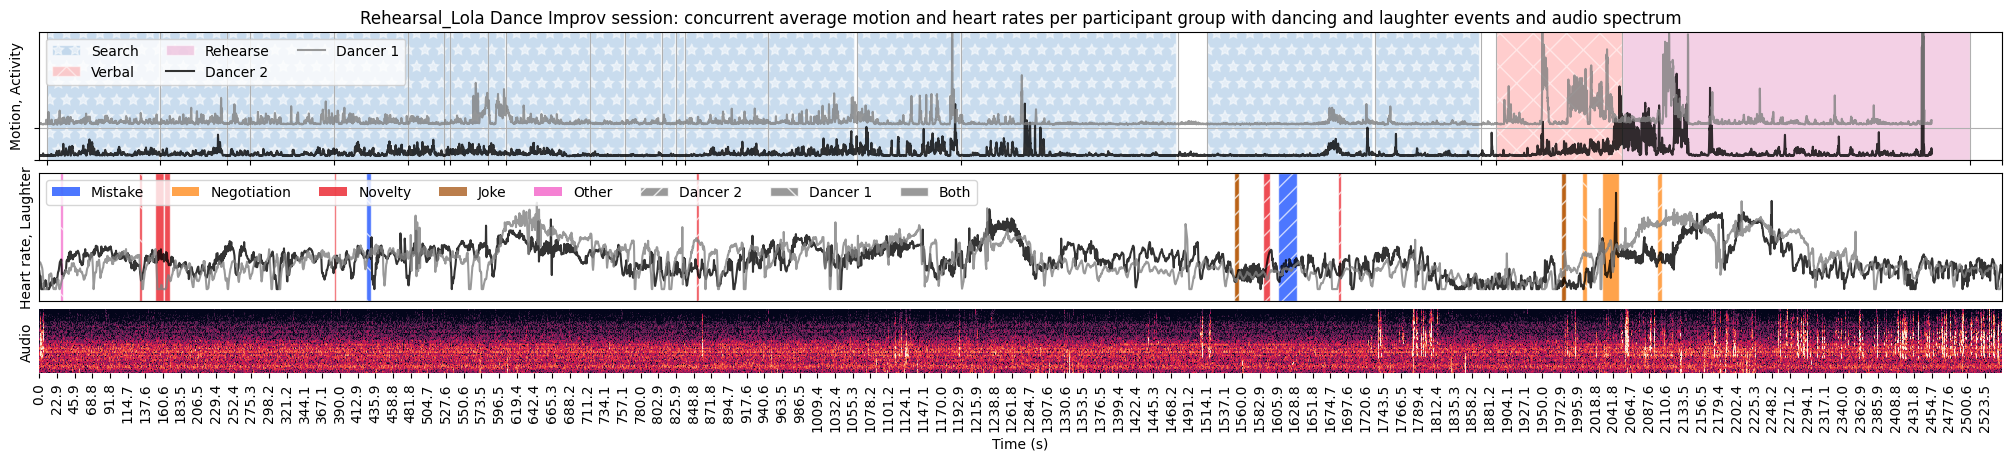

In [64]:
s_time = times[0]
e_time = altT[-1]# 3376.0 #760.0 #times[-1]

fig3 = plt.figure(constrained_layout=True,figsize=(20,4.5))
gs = fig3.add_gridspec(5, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4, :])


ax=axes[0]
# legend prep
sub_events = dancings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.LABEL.str[0].unique())
for e in sub_eventTypes: 
    if e in code_eventType.keys():
        ev = code_eventType[e]
        ax.axvspan(-1,-0.5, facecolor=event_pallet[ev],hatch=event_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
ax.legend(loc='upper left')


# main plot
df_feats = df_allfeats['ACC_QoM'].copy()
cols = df_feats.columns
shift_d = 100
for counter_i in range(len(alist)):
    partID = alist[counter_i]
    ax.plot(df_feats[partID]+counter_i*shift_d,color=player_pallet[player_labels[partID]],alpha=0.8,label=player_labels[partID])
ax.legend(ncol=3,loc='upper left')
ax.set(xlim = [s_time,e_time],ylim = [0,4*shift_d],xticks=dancings['TIME'],xticklabels = [],yticks = [0,shift_d])
ax.set(yticklabels=[],ylabel='Motion, Activity') 
ax.grid()

A = laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
for ev in events_types: viz.annat_shade(ax,dancings.query('LABEL.str.startswith(@ev[0])'),event_pallet[ev],event_hatch[ev],0.5)

ax.set_title(piece+' Dance Improv session: concurrent average motion and heart rates per participant group with dancing and laughter events and audio spectrum')

ax=axes[1]
A = laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['Dancer 2'],edgecolor="w",alpha = 0.8,label='Dancer 2')
ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['Dancer 1'],edgecolor="w",alpha = 0.8,label='Dancer 1')
ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['contagious'],edgecolor="w",alpha = 0.8,label='Both')

ax.legend(ncol=len(sub_whats)+3,loc='upper left')

df_feats = df_allfeats['normHR1bt_smoothed'].copy()
for partID in alist:
    ax.plot(df_feats[partID],color =player_pallet[player_labels[partID]],alpha=0.8,label=partID)
ax.set(xlim = [s_time,e_time],ylim = [-0.4,1.8],xticks=[],yticks=[])
ax.grid()
# ax.legend()
ax.set(yticklabels=[],ylabel='Heart rate, Laughter') 
for who in ['Dancer 2', 'Dancer 1', 'simultaneous', 'contagious']:
    sub_laughs = laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.7)

ax=axes[2] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/DanceImprov_'+piece+'_Full_Annotated_Events_Laughs_Audio.png',bbox_inches = 'tight',dpi = mydpi)

plt.show()

## Plot excerpts of session


134    together,simultanoues, house start, enjoyment,...
136    together,simultanoues, difficulty level hardsh...
Name: LABEL, dtype: object


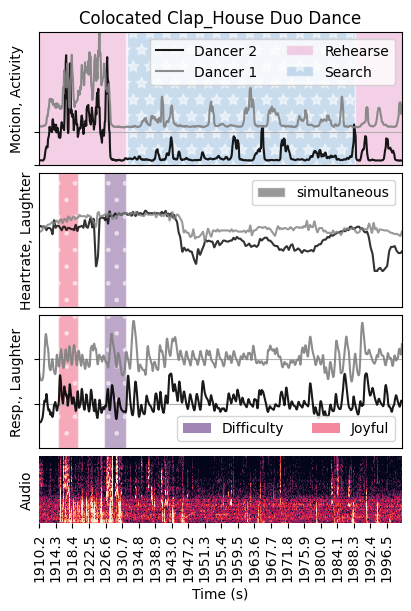

In [37]:
# Colocated = {'Bump':220,'Meow':1335 ,'Clapping':1653.481, 'Clap_House':1910.130}
# zoom2 = {'Solo':1570,'Verbal': 1970,'Camera_Confusion':1608.065 }
# lola = {'Playful':2150, 'Difficult_Pose': 1400, 'Novelty_Negotiation':2043.849}

seg_tag = 'Clap_House'
s_time = 1910.130 
e_time = s_time + 90

sub_events = dancings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.LABEL.str[0].unique())

sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
print(sub_laughs.LABEL)
A = sub_laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
sub_who = list(sub_laughs.Who.unique())



fig3 = plt.figure(constrained_layout=True,figsize=(4,6))
gs = fig3.add_gridspec(7, 1)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4:6, :])
axes[3] = fig3.add_subplot(gs[6, :])

ax=axes[0]
df_feats = df_allfeats['ACC_QoM'].copy()
cols = df_feats.columns
shift_d = 100
for counter_i in range(len(alist)):
    partID = alist[counter_i]
    ax.plot(df_feats[partID]+counter_i*shift_d,color =player_pallet[player_labels[partID]],alpha=0.9,label=player_labels[partID])

for e in sub_eventTypes: 
    if e in code_eventType.keys():
        ev = code_eventType[e]
        ax.axvspan(-1,-0.5, facecolor=event_pallet[ev],hatch=event_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
ax.legend(ncol=2,loc='best')
ax.set(xlim = [s_time,e_time],ylim = [0,4*shift_d],xticks=[],yticks = [0,shift_d])
ax.set(yticklabels=[],ylabel='Motion, Activity') 

ax.grid()
for ev in events_types: viz.annat_shade(ax,dancings.query('LABEL.str.startswith(@ev[0])'),event_pallet[ev],event_hatch[ev],0.5)

ax.set_title(concert+' '+seg_tag+' Duo Dance')

ax=axes[1]
for who in sub_who: ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
ax.legend(loc='best')
df_feats = df_allfeats['normHR1bt_smoothed'].copy()
for partID in alist:
    ax.plot(df_feats[partID],color =player_pallet[player_labels[partID]],alpha=0.8,label=partID)
ax.set(xlim = [s_time,e_time],ylim = [-1,2],xticks=[],yticks = [])
ax.grid()
ax.set(yticklabels=[],ylabel='Heartrate, Laughter') 
for who in ['Dancer 2','Dancer 1', 'simultaneous', 'contagious']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.5)


ax=axes[2]
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.legend(ncol=2,loc='best')
df_feats = df_allfeats['RespWave'].copy()
shift_d = 5
for counter_i in range(len(alist)):
    partID = alist[counter_i]
    ax.plot(df_feats[partID]+counter_i*shift_d,color =player_pallet[player_labels[partID]],alpha=0.9,label=player_labels[partID])
ax.set(xlim = [s_time,e_time],ylim = [-5,10],xticks=[],yticks = [0,shift_d])
ax.grid()
# ax.legend()
ax.set(yticklabels=[],ylabel='Resp., Laughter') 
for who in ['Dancer 2','Dancer 1', 'simultaneous', 'contagious']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.5)
        
ax=axes[3] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/DanceImprov_'+seg_tag+'_'+piece+'_Cascade_HR_QoM_audio.png',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Laughter counts
Generate the counts of laughter from each session, by who and by what function

In [39]:
all_Laughs = []
for concert in offsets.keys():
    shift_s = offsets[concert]
    Event_timings = pd.read_csv(misc_loc +segmentationfiles[concert],skiprows=1)
    dancings = pd.DataFrame()
    dancings['TIME'] = Event_timings['Begin Time - ss.msec']
    dancings['DURATION'] = Event_timings['Duration - ss.msec']
    dancings['LABEL'] = Event_timings['Seg_code']
    events_types = ['Search','Clean','Rehearse','Verbal']
    sub_eventTypes = list(dancings.LABEL.str[0].unique()) 
    b = list(set(code_eventType.keys()) & set(sub_eventTypes))
    
    eventType_code = dict(zip(events_types,['S','C','R','V']))
    code_eventType =  dict(zip(['S','C','R','V'],events_types))
    
    sub_eventTypes = list(dancings.LABEL.str[0].unique()) 
    b = list(set(['S','C','R','V']) & set(sub_eventTypes))
    print(b)
    con_cols =  {}
    for ev in b: con_cols[ev] = (concert[:2] +'_'+ code_eventType[ev])
    
    annotates = pd.read_csv(misc_loc +annotationfiles[concert],skiprows=1)
    
    laughs = pd.DataFrame()
    laughs['TIME'] = annotates['Begin Time - ss.msec']
    laughs['DURATION'] = annotates['Duration - ss.msec']
    laughs['LABEL'] = annotates['Laughter'].str.lower()
    laughs = laughs.loc[laughs.LABEL.str.len()>2,:].copy()
    
    # 1.First parameter circulation of laughter : solo, contagious, simultaneous
    laughs['Who'] = ''
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("ole")').index,'Who'] = 'Dancer 1'
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("lisa")').index,'Who'] = 'Dancer 2'
    laughs.loc[laughs.query('LABEL.str.contains("contag")').index,'Who'] = 'contagious'
    laughs.loc[laughs.query('LABEL.str.contains("simultan")').index,'Who'] = 'simultaneous'
    
    #Mistake 	Negociation 	Communicating difficulty 	Novelty and Surprise 	Joyful 	Verbal Joke
    laughs['Mistake'] = 0 # Mistakes and Confusion (labels: mistake, confusion) ,
    laughs.loc[laughs.query('LABEL.str.contains("mistake")').index ,'Mistake'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("confusion")').index ,'Mistake'] = 1
    laughs['Negotiation'] = 0 # Negotiation (label: agreement, disagreement, negotiation),
    laughs.loc[laughs.query('LABEL.str.contains("agreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("disagreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("negotiation")').index ,'Negotiation'] = 1
    
    laughs['Difficulty'] = 0 # Communicating difficulty level (label: difficulty level)
    laughs.loc[laughs.query('LABEL.str.contains("difficult")').index ,'Difficulty'] = 1
    
    laughs['Novelty'] = 0 # Novelty and Surprise (label: Novelty and Suprise) ,
    laughs.loc[laughs.query('LABEL.str.contains("novelty and suprise")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("novelty")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("suprise")').index ,'Novelty'] = 1
    
    laughs['Joyful'] = 0 # Playfulness (label Playfulness )
    laughs.loc[laughs.query('LABEL.str.contains("playful")').index ,'Joyful'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("enjoyment")').index ,'Joyful'] = 1
    
    laughs['Joke'] = 0
    laughs.loc[laughs.query('LABEL.str.contains("joke")').index ,'Joke'] = 1
    
    laughs['Other'] = 1
    laughs.loc[laughs[['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke']].sum(axis=1)>0,'Other'] = 0

    Laugh_Counts = pd.DataFrame(index = whats,columns = sub_eventTypes,data=0)

    for i,row in dancings.iterrows():
        s_time = row['TIME']
        e_time = row['TIME'] + row['DURATION']
        sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
        Laugh_Counts.loc[whats,row['LABEL'][0]]+=sub_laughs.loc[:,whats].sum() #concert[:2]+'_'+
    
    A = Laugh_Counts.rename(con_cols,axis=1)
    all_Laughs.append(A.loc[:,list(con_cols.values())])

['V', 'C', 'S', 'R']
['V', 'S', 'R']
['V', 'S']


In [40]:
All_Laugh_Counts = pd.concat(all_Laughs,axis=1)
All_Laugh_Counts
print(All_Laugh_Counts.to_latex())

\begin{tabular}{lrrrrrrrrr}
\toprule
 & Co_Verbal & Co_Clean & Co_Search & Co_Rehearse & Zo_Verbal & Zo_Search & Zo_Rehearse & Lo_Verbal & Lo_Search \\
\midrule
Mistake & 0 & 4 & 7 & 9 & 0 & 2 & 0 & 0 & 0 \\
Negotiation & 0 & 3 & 12 & 10 & 9 & 0 & 1 & 6 & 2 \\
Difficulty & 0 & 2 & 1 & 3 & 0 & 0 & 0 & 0 & 3 \\
Novelty & 0 & 6 & 14 & 0 & 0 & 8 & 0 & 0 & 7 \\
Joyful & 0 & 0 & 3 & 9 & 0 & 0 & 0 & 0 & 8 \\
Joke & 0 & 3 & 5 & 0 & 2 & 0 & 0 & 0 & 0 \\
Other & 1 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
\bottomrule
\end{tabular}



In [46]:
all_Laughs = []
for concert in offsets.keys():
    
    annotates = pd.read_csv(misc_loc +annotationfiles[concert],skiprows=1)
    
    laughs = pd.DataFrame()
    laughs['TIME'] = annotates['Begin Time - ss.msec']
    laughs['DURATION'] = annotates['Duration - ss.msec']
    laughs['LABEL'] = annotates['Laughter'].str.lower()
    laughs = laughs.loc[laughs.LABEL.str.len()>2,:].copy()
    
    # 1.First parameter circulation of laughter : solo, contagious, simultaneous
    laughs['Who'] = ''
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("ole")').index,'Who'] = 'Dancer 1'
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("lisa")').index,'Who'] = 'Dancer 2'
    laughs.loc[laughs.query('LABEL.str.contains("contag")').index,'Who'] = 'contagious'
    laughs.loc[laughs.query('LABEL.str.contains("simultan")').index,'Who'] = 'simultaneous'
    
    #Mistake 	Negociation 	Communicating difficulty 	Novelty and Surprise 	Joyful 	Verbal Joke
    laughs['Mistake'] = 0 # Mistakes and Confusion (labels: mistake, confusion) ,
    laughs.loc[laughs.query('LABEL.str.contains("mistake")').index ,'Mistake'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("confusion")').index ,'Mistake'] = 1
    laughs['Negotiation'] = 0 # Negotiation (label: agreement, disagreement, negotiation),
    laughs.loc[laughs.query('LABEL.str.contains("agreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("disagreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("negotiation")').index ,'Negotiation'] = 1
    
    laughs['Difficulty'] = 0 # Communicating difficulty level (label: difficulty level)
    laughs.loc[laughs.query('LABEL.str.contains("difficult")').index ,'Difficulty'] = 1
    
    laughs['Novelty'] = 0 # Novelty and Surprise (label: Novelty and Suprise) ,
    laughs.loc[laughs.query('LABEL.str.contains("novelty and suprise")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("novelty")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("suprise")').index ,'Novelty'] = 1
    
    laughs['Joyful'] = 0 # Playfulness (label Playfulness )
    laughs.loc[laughs.query('LABEL.str.contains("playful")').index ,'Joyful'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("enjoyment")').index ,'Joyful'] = 1
    
    laughs['Joke'] = 0
    laughs.loc[laughs.query('LABEL.str.contains("joke")').index ,'Joke'] = 1
    
    laughs['Other'] = 1
    laughs.loc[laughs[['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke']].sum(axis=1)>0,'Other'] = 0

    Laugh_Counts = pd.DataFrame(index = whats)

    s_time = 0
    e_time = concert_dur[concert] 
    
    whos = ['ole', 'lisa']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
    B = (sub_laughs.loc[:,['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
    Laugh_Counts.loc[:,concert + ' Solo'] = B
    
    whos = ['simultaneous']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
    B = (sub_laughs.loc[:,['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
    Laugh_Counts.loc[:,concert+' simultaneous'] = B
    
    whos = ['contagious']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
    B = (sub_laughs.loc[:,['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
    Laugh_Counts.loc[:,concert+ ' contagious'] = B
    all_Laughs.append(Laugh_Counts)

In [48]:
All_Laugh_Counts = pd.concat(all_Laughs,axis=1)
All_Laugh_Counts
print(All_Laugh_Counts.to_latex())

\begin{tabular}{lrrrrrrrrr}
\toprule
 & Colocated Solo & Colocated simultaneous & Colocated contagious & Zoom2 Solo & Zoom2 simultaneous & Zoom2 contagious & Lola Solo & Lola simultaneous & Lola contagious \\
\midrule
Mistake & 0 & 7 & 7 & 0 & 0 & 0 & 0 & 0 & 0 \\
Negotiation & 0 & 1 & 9 & 0 & 3 & 1 & 0 & 0 & 3 \\
Difficulty & 0 & 3 & 2 & 0 & 0 & 0 & 0 & 1 & 2 \\
Novelty & 0 & 3 & 8 & 0 & 0 & 4 & 0 & 0 & 4 \\
Joyful & 0 & 4 & 2 & 0 & 0 & 0 & 0 & 0 & 2 \\
Joke & 0 & 0 & 6 & 0 & 0 & 0 & 0 & 0 & 0 \\
Other & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
\bottomrule
\end{tabular}

